# Autoresearch Experiment Analysis

Analysis of autonomous EMR model tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 6 columns)
df = pd.read_csv("results.tsv", sep="\t")
df["outcome_auroc"] = pd.to_numeric(df["outcome_auroc"], errors="coerce")
df["val_bce_loss"]  = pd.to_numeric(df["val_bce_loss"],  errors="coerce")
df["memory_gb"]     = pd.to_numeric(df["memory_gb"],     errors="coerce")
df["status"]        = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 60
Columns: ['commit', 'outcome_auroc', 'val_bce_loss', 'memory_gb', 'status', 'description']


,commit,outcome_auroc,val_bce_loss,memory_gb,status,description
0,854206a,0.645301,0.480291,12.1,KEEP,baseline
1,50a2e10,0.660346,0.480298,12.1,KEEP,outcome to Stage1 + fraction_cap 0.5->1.0
2,62e1d8b,0.668950,0.479078,17.3,KEEP,temporal 48h outcome targets aligned with eval...
3,680f0b8,0.684883,0.478557,18.3,KEEP,embed_dim 64->96 (2.25x capacity)
4,d465078,0.668660,0.482070,17.8,DISCARD,n_layer 4->5 (no improvement)
5,e22991f,0.666554,0.476691,17.7,DISCARD,n_head 4->8 (8 dims/head too narrow)
6,330a6d9,0.669461,0.475075,18.5,DISCARD,n_layer 4->6 (depth hurts outcome_auroc despit...
7,4ff06b6,0.684740,0.407758,20.2,DISCARD,sample 2000->3000 (no AUROC gain)
8,9a3bb86,0.676456,0.456862,18.7,DISCARD,"focal BCE + deeper outcome head (better BCE, w..."
9,d3ff171,0.672245,0.431576,18.7,DISCARD,direct LM-logit temporal BCE (gradient conflic...


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep    = counts.get("KEEP",    0)
n_discard = counts.get("DISCARD", 0)
n_crash   = counts.get("CRASH",   0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD     41
KEEP        17
CRASH        1
BASELINE     1

Keep rate: 17/58 = 29.3%


In [3]:
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    auroc = row["outcome_auroc"]
    bce   = row["val_bce_loss"]
    desc  = row["description"]
    print(f"  #{i:3d}  outcome_auroc={auroc:.6f}  val_bce={bce:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (17 total):

  #  0  outcome_auroc=0.645301  val_bce=0.480291  mem=12.1GB  baseline
  #  1  outcome_auroc=0.660346  val_bce=0.480298  mem=12.1GB  outcome to Stage1 + fraction_cap 0.5->1.0
  #  2  outcome_auroc=0.668950  val_bce=0.479078  mem=17.3GB  temporal 48h outcome targets aligned with eval metric
  #  3  outcome_auroc=0.684883  val_bce=0.478557  mem=18.3GB  embed_dim 64->96 (2.25x capacity)
  # 11  outcome_auroc=0.693178  val_bce=0.442528  mem=19.0GB  embed_dim 96->128: Hypoglycemia +0.101, Cardio +0.063
  # 12  outcome_auroc=0.696819  val_bce=0.419428  mem=20.3GB  embed_dim 128->192: diminishing gains (+0.004)
  # 13  outcome_auroc=0.700777  val_bce=0.314289  mem=23.1GB  embed_dim 192->256: crossed 0.70 AUROC
  # 17  outcome_auroc=0.722311  val_bce=0.557637  mem=25.0GB  12h temporal BCE + (12h,48h] outcome window (non-overlapping)
  # 22  outcome_auroc=0.734107  val_bce=0.497383  mem=25.0GB  fix gradient starvation: ce cap 0.2->2.0, outcome cap 1.0->10.0
  # 27 

## Outcome AUROC Over Time

Track how the best (kept) `outcome_auroc` evolves as experiments progress.

**Primary metric**: mean per-outcome ROC-AUC averaged across all complication types.
For each type, label=1 at positions where *that specific* complication is in the next 5 steps,
score=logit for that token. 0.5 = random, 1.0 = perfect.

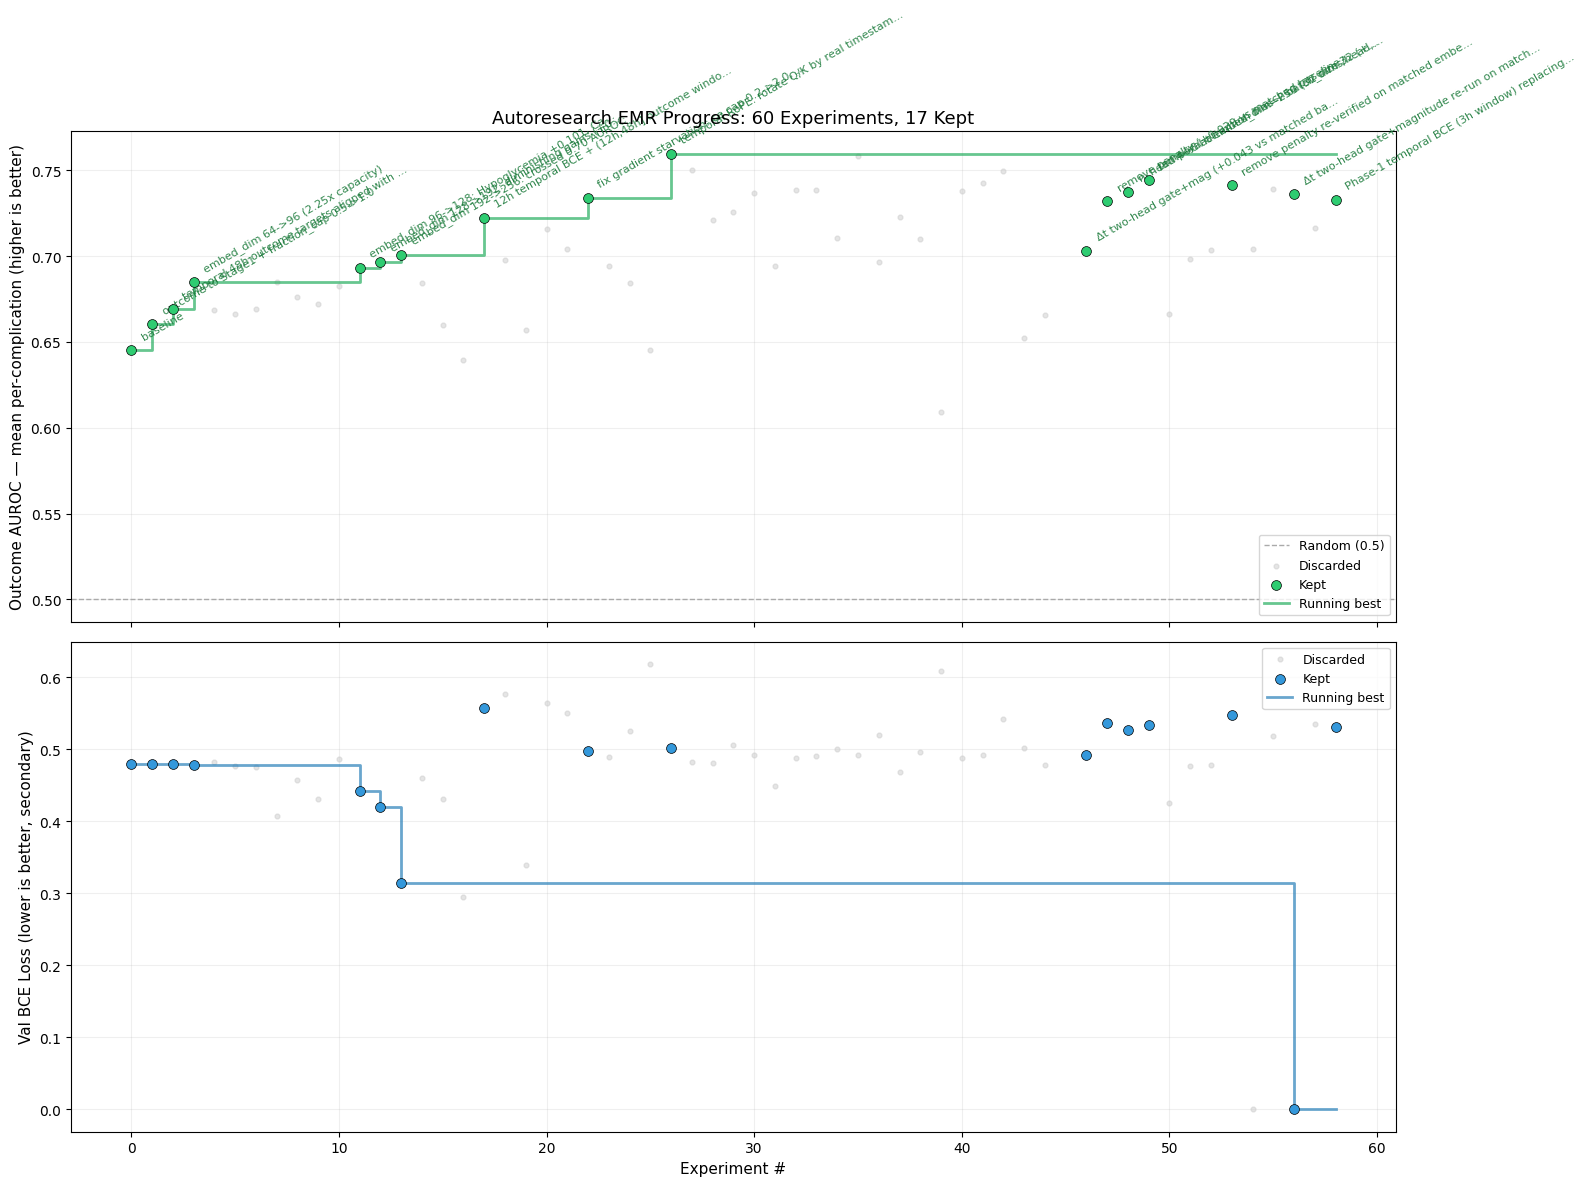

Saved to progress.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

valid = df[df["status"] != "CRASH"].copy().reset_index(drop=True)
kept_mask = valid["status"] == "KEEP"
kept_idx  = valid.index[kept_mask]
kept_v    = valid[kept_mask]
disc      = valid[valid["status"] == "DISCARD"]

# ── Top: outcome AUROC (primary) ─────────────────────────────────────────────
ax = axes[0]
ax.axhline(0.5, color="#aaaaaa", linewidth=1, linestyle="--", label="Random (0.5)")
ax.scatter(disc.index, disc["outcome_auroc"], c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")
ax.scatter(kept_v.index, kept_v["outcome_auroc"], c="#2ecc71", s=50, zorder=4,
           label="Kept", edgecolors="black", linewidths=0.5)
running_max = kept_v["outcome_auroc"].cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60", linewidth=2, alpha=0.7, zorder=3, label="Running best")

for idx, auroc in zip(kept_idx, kept_v["outcome_auroc"]):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."
    ax.annotate(desc, (idx, auroc), textcoords="offset points", xytext=(6, 6),
                fontsize=8, color="#1a7a3a", alpha=0.9, rotation=30, ha="left", va="bottom")

ax.set_ylabel("Outcome AUROC — mean per-complication (higher is better)", fontsize=11)
ax.set_title(f"Autoresearch EMR Progress: {len(df)} Experiments, {kept_mask.sum()} Kept", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# ── Bottom: val BCE (secondary / sanity) ────────────────────────────────────
ax2 = axes[1]
ax2.scatter(disc.index, disc["val_bce_loss"], c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")
ax2.scatter(kept_v.index, kept_v["val_bce_loss"], c="#3498db", s=50, zorder=4,
            label="Kept", edgecolors="black", linewidths=0.5)
running_min_bce = kept_v["val_bce_loss"].cummin()
ax2.step(kept_idx, running_min_bce, where="post", color="#2980b9", linewidth=2, alpha=0.7, zorder=3, label="Running best")

ax2.set_xlabel("Experiment #", fontsize=11)
ax2.set_ylabel("Val BCE Loss (lower is better, secondary)", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
kept          = df[df["status"] == "KEEP"].copy()
baseline_auroc = df.iloc[0]["outcome_auroc"]
baseline_bce   = df.iloc[0]["val_bce_loss"]
best_auroc     = kept["outcome_auroc"].max()
best_row       = kept.loc[kept["outcome_auroc"].idxmax()]

print(f"Baseline outcome_auroc:  {baseline_auroc:.6f}")
print(f"Best outcome_auroc:      {best_auroc:.6f}")
print(f"Total improvement:       {best_auroc - baseline_auroc:+.6f}  "
      f"({(best_auroc - baseline_auroc) / max(baseline_auroc, 1e-9) * 100:.2f}%)")
print(f"Best experiment:         {best_row['description']}")
print()
print(f"Baseline val_bce_loss:   {baseline_bce:.6f}")
print(f"Best val_bce_loss:       {kept['val_bce_loss'].min():.6f}")
print()

print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for _, row in kept_sorted.iterrows():
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: outcome_auroc={row['outcome_auroc']:.6f}  val_bce={row['val_bce_loss']:.6f}  {desc}")

Baseline outcome_auroc:  0.645301
Best outcome_auroc:      0.759719
Total improvement:       +0.114418  (17.73%)
Best experiment:         temporal RoPE: rotate Q/K by real timestamps instead of position index

Baseline val_bce_loss:   0.480291
Best val_bce_loss:       0.000000

Cumulative effort per improvement:
  Experiment #  0: outcome_auroc=0.645301  val_bce=0.480291  baseline
  Experiment #  1: outcome_auroc=0.660346  val_bce=0.480298  outcome to Stage1 + fraction_cap 0.5->1.0
  Experiment #  2: outcome_auroc=0.668950  val_bce=0.479078  temporal 48h outcome targets aligned with eval metric
  Experiment #  3: outcome_auroc=0.684883  val_bce=0.478557  embed_dim 64->96 (2.25x capacity)
  Experiment # 11: outcome_auroc=0.693178  val_bce=0.442528  embed_dim 96->128: Hypoglycemia +0.101, Cardio +0.063
  Experiment # 12: outcome_auroc=0.696819  val_bce=0.419428  embed_dim 128->192: diminishing gains (+0.004)
  Experiment # 13: outcome_auroc=0.700777  val_bce=0.314289  embed_dim 192->256:

## Top Hits (Kept Experiments by Improvement)

In [6]:
kept = df[df["status"] == "KEEP"].copy()
kept["prev_auroc"] = kept["outcome_auroc"].shift(1)
kept["delta"]      = kept["outcome_auroc"] - kept["prev_auroc"]

hits = kept.iloc[1:].copy().sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'AUROC':>8}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['outcome_auroc']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>8}  TOTAL improvement over baseline")

Rank     Delta     AUROC  Description
--------------------------------------------------------------------------------
   1  +0.028720  0.731944  remove penalty (+0.029 vs matched baseline 0.703, earlier outcome activation)
   2  +0.025612  0.759719  temporal RoPE: rotate Q/K by real timestamps instead of position index
   3  +0.021534  0.722311  12h temporal BCE + (12h,48h] outcome window (non-overlapping)
   4  +0.015933  0.684883  embed_dim 64->96 (2.25x capacity)
   5  +0.015045  0.660346  outcome to Stage1 + fraction_cap 0.5->1.0
   6  +0.011796  0.734107  fix gradient starvation: ce cap 0.2->2.0, outcome cap 1.0->10.0
   7  +0.008604  0.668950  temporal 48h outcome targets aligned with eval metric
   8  +0.008295  0.693178  embed_dim 96->128: Hypoglycemia +0.101, Cardio +0.063
   9  +0.006933  0.744464  temporal attention bias + batch_size 32 (+0.007 despite batch penalty)
  10  +0.005587  0.737531  n_head 4→8 at embed_dim=256 (32 dims/head, +0.006)
  11  +0.003958  0.700777  emb